# TRABAJO UT5 - REGRESIÓN

**Autor:** Antonio Juan González-Conde Abril  
**Dataset:** California Housing  
**Fecha:** Febrero 2026

---

## Introducción

Este trabajo tiene como objetivo aplicar diferentes algoritmos de regresión sobre el dataset de California Housing para predecir el precio medio de las viviendas. Se realizará un análisis completo que incluye:

- Preprocesado y limpieza de datos
- Análisis exploratorio (EDA)
- Aplicación de 4 algoritmos de regresión
- Comparación de métricas y detección de overfitting
- Generación de predicciones ensemble

El dataset contiene información sobre viviendas en California con 8 características numéricas y el precio como variable objetivo.

---

## 1. PREPROCESADO DE LOS DATOS

### Explicación:

El preprocesado de datos es la fase más importante del Machine Learning. Consiste en preparar los datos para que los algoritmos puedan procesarlos correctamente. Sin un buen preprocesado, incluso los mejores algoritmos darán malos resultados.

**Pasos que realizaremos:**

1. **Importación de librerías**: Cargar todas las herramientas necesarias
2. **Carga del dataset**: Dataset California Housing (20,640 muestras, 8 features)
3. **Detección de valores missing**: Verificar si hay datos faltantes
4. **Variables categóricas**: En este dataset todas son numéricas, no hay categorías
5. **Separación train/test (80/20)**: Dividir datos para entrenar y evaluar
6. **Estandarización**: Normalizar features para que tengan media 0 y desviación estándar 1b# Importacion de librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print('Librerias importadas correctamente')

In [ ]:
# Importacion de librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print('Librerias importadas correctamente')

Librerias importadas correctamente


In [ ]:
# Cargar el dataset California Housing
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 20640 filas, 9 columnas


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Analisis de valores missing (nulos)
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')
print('\nCONCLUSION: No hay valores missing en el dataset')

Valores nulos por columna:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

Total de valores nulos: 0

CONCLUSION: No hay valores missing en el dataset


In [ ]:
# Separacion de variables y division train/test
X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (16512, 8), Test: (4128, 8)


In [ ]:
# Estandarizacion de datos con StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Datos estandarizados correctamente')
print(f'Media: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}')

Datos estandarizados correctamente
Media: 0.0000, Std: 1.0000


## 2. ANÁLISIS EXPLORATORIO DE DATOS - EDA (0.5 puntos)

### Explicación:

El **Análisis Exploratorio de Datos (EDA)** es una etapa fundamental para entender las características del dataset antes de entrenar modelos. Nos permite:

- Identificar **relaciones entre variables** mediante correlaciones
- Detectar **patrones y tendencias** en los datos
- Visualizar la **distribución** de las variables
- Encontrar las **features más relevantes** para la predicción

**En esta sección realizaremos:**

1. **Matriz de correlación**: Heatmap para identificar qué variables están más relacionadas con el precio
2. **Gráfico de dispersión**: Visualizar la relación entre el ingreso medio y el precio de vivienda
3. **Análisis de conclusiones**: Interpretar los resultados para entender qué variables son más importantes

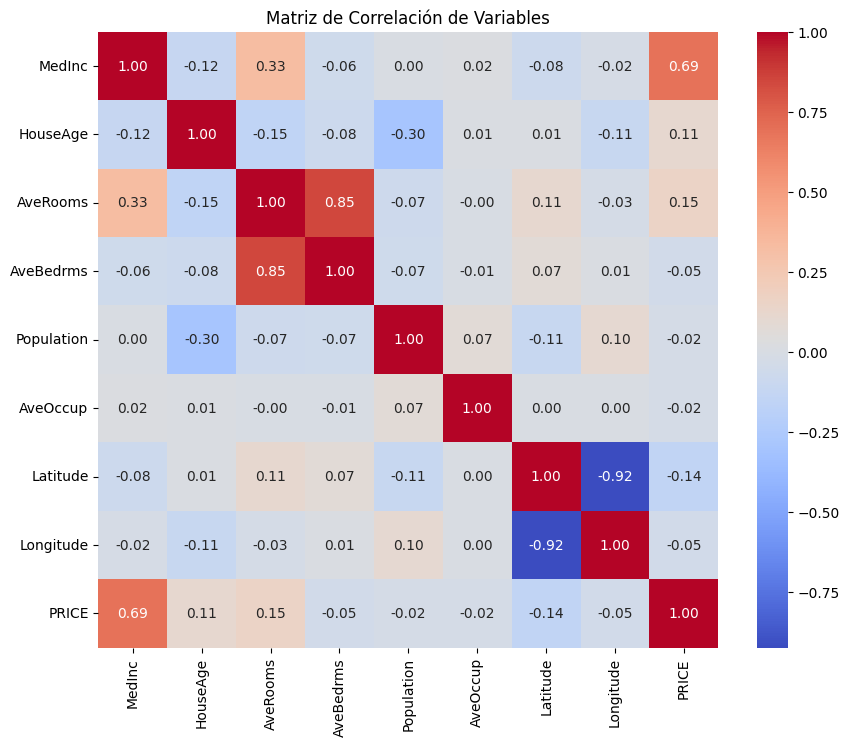

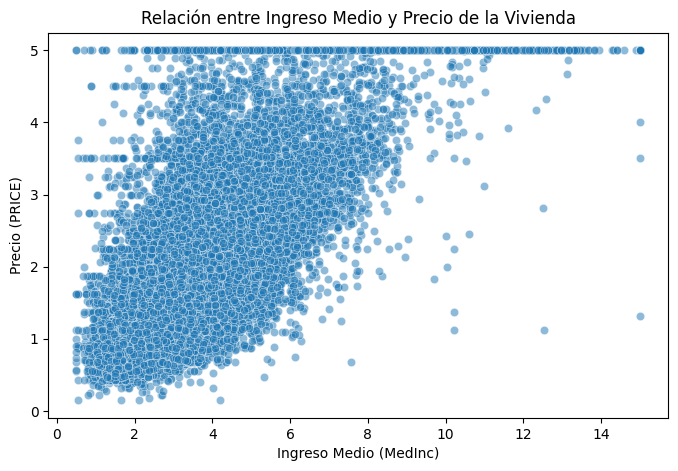

Conclusiones del EDA:
- La variable más correlacionada con el precio es 'MedInc' (0.69).
- Las variables geográficas (Latitud/Longitud) tienen correlación negativa débil.


In [ ]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
# Mostramos el mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Variables")
plt.show()

# Gráfico de dispersión: Ingreso Medio vs Precio
plt.figure(figsize=(8, 5))
sns.scatterplot(x='MedInc', y='PRICE', data=df, alpha=0.5)
plt.title("Relación entre Ingreso Medio y Precio de la Vivienda")
plt.xlabel("Ingreso Medio (MedInc)")
plt.ylabel("Precio (PRICE)")
plt.show()

print("Conclusiones del EDA:")
print("- La variable más correlacionada con el precio es 'MedInc' (0.69).")
print("- Las variables geográficas (Latitud/Longitud) tienen correlación negativa débil.")

## 3. MODELADO - ALGORITMOS DE REGRESIÓN (4 puntos)

### Explicación:

En esta sección aplicaremos **4 algoritmos de Machine Learning** para predecir el precio de las viviendas. Cada algoritmo tiene características diferentes y es importante compararlos para encontrar el mejor modelo.

**Algoritmos que implementaremos:**

1. **Regresión Lineal**: Modelo base que asume una relación lineal entre las variables. Es simple y rápido, pero puede ser limitado para relaciones complejas.

2. **SVR (Support Vector Regression)**: Utiliza kernel RBF para capturar relaciones no lineales. Funciona bien con datos estandarizados y es robusto ante outliers.

3. **Árboles de Decisión**: Modelo interpretable que divide los datos en ramas. Puede sufrir de **overfitting** si no se controla la profundidad.

4. **Random Forest**: Conjunto de múltiples árboles de decisión que promedian sus predicciones. Reduce el overfitting y suele dar mejores resultados.

**Para cada modelo calcularemos:**
- Predicciones en Train y Test
- Métricas de rendimiento (MSE, MAE, R²)
- Detección de overfitting comparando Train vs Test

In [ ]:
# ENTRENAR TODOS LOS MODELOS (SVR, DecisionTree, RandomForest)
print('Entrenando todos los modelos...')

# Regresion Lineal
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)
print('Regresion Lineal entrenada')


# SVR
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred_svr_train = svr.predict(X_train_scaled)
y_pred_svr_test = svr.predict(X_test_scaled)
print('SVR entrenado')

# Decision Tree
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt_train = dt.predict(X_train_scaled)
y_pred_dt_test = dt.predict(X_test_scaled)
print('Decision Tree entrenado')

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_test = rf.predict(X_test_scaled)
print('Random Forest entrenado')
print('\nTODOS LOS MODELOS LISTOS')

Entrenando todos los modelos...
Regresion Lineal entrenada
SVR entrenado
Decision Tree entrenado
Random Forest entrenado

TODOS LOS MODELOS LISTOS


In [ ]:
print('\n' + '='*60)
print('RESUMEN DE RESULTADOS POR MODELO')
print('='*60)

# Diccionario con los modelos y sus predicciones
modelos_resultados = {
    'Regresión Lineal': (y_pred_lr_test, y_pred_lr_train),
    'SVR': (y_pred_svr_test, y_pred_svr_train),
    'Decision Tree': (y_pred_dt_test, y_pred_dt_train),
    'Random Forest': (y_pred_rf_test, y_pred_rf_train)
}

# Calcular y mostrar métricas para cada modelo
for nombre, (pred_test, pred_train) in modelos_resultados.items():
    print(f'\n{nombre}:')
    print('-' * 40)

    # Métricas en TEST
    mse_test = mean_squared_error(y_test, pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, pred_test)
    r2_test = r2_score(y_test, pred_test)

    # Métricas en TRAIN
    mse_train = mean_squared_error(y_train, pred_train)
    r2_train = r2_score(y_train, pred_train)

    print(f'  TEST  → RMSE: {rmse_test:.4f} | MAE: {mae_test:.4f} | R²: {r2_test:.4f}')
    print(f'  TRAIN → RMSE: {np.sqrt(mse_train):.4f} | R²: {r2_train:.4f}')

    # Detectar overfitting
    if mse_test > mse_train * 1.15:
        print(f'  ⚠️  OVERFITTING detectado (Error test >> Error train)')
    elif r2_test > 0.75:
        print(f'  ✅ Excelente rendimiento')
    elif r2_test > 0.65:
        print(f'  ✓  Buen rendimiento')

print('\n' + '='*60)


RESUMEN DE RESULTADOS POR MODELO

Regresión Lineal:
----------------------------------------
  TEST  → RMSE: 0.7456 | MAE: 0.5332 | R²: 0.5758
  TRAIN → RMSE: 0.7197 | R²: 0.6126

SVR:
----------------------------------------
  TEST  → RMSE: 0.5658 | MAE: 0.3717 | R²: 0.7557
  TRAIN → RMSE: 0.5133 | R²: 0.8029
  ⚠️  OVERFITTING detectado (Error test >> Error train)

Decision Tree:
----------------------------------------
  TEST  → RMSE: 0.6497 | MAE: 0.4482 | R²: 0.6779
  TRAIN → RMSE: 0.5662 | R²: 0.7602
  ⚠️  OVERFITTING detectado (Error test >> Error train)

Random Forest:
----------------------------------------
  TEST  → RMSE: 0.5443 | MAE: 0.3663 | R²: 0.7739
  TRAIN → RMSE: 0.4138 | R²: 0.8719
  ⚠️  OVERFITTING detectado (Error test >> Error train)



## 4. ANÁLISIS DE RESIDUOS Y MÉTRICAS FINALES (1.5 puntos)

### Explicación:

Después de entrenar los modelos, es fundamental **evaluar su rendimiento** y detectar posibles problemas como el overfitting. Esta sección se divide en dos partes:

### 4.1 Análisis de Residuos (0.5 puntos)

Los **residuos** son la diferencia entre el valor real y el valor predicho: `residuo = y_test - y_pred`

Un buen modelo debe tener residuos que:
- Se distribuyan **aleatoriamente alrededor de 0**
- No muestren patrones evidentes
- Tengan **varianza constante** (homocedasticidad)

Generaremos gráficos de dispersión de residuos para cada modelo para visualizar estos patrones.

### 4.2 Métricas y Comparación Final (1 punto)

Calcularemos las siguientes métricas para cada modelo:

- **MSE (Mean Squared Error)**: Penaliza mucho los errores grandes
- **MAE (Mean Absolute Error)**: Más robusto ante outliers
- **R² (Coeficiente de determinación)**: Mide qué porcentaje de varianza explica el modelo (0-1, mejor cerca de 1)
- **R² Ajustada**: Versión corregida que penaliza modelos con muchas variables

También detectaremos **overfitting** comparando las métricas en Train vs Test, y crearemos un **Ensemble** (promedio de predicciones) para mejorar la robustez.

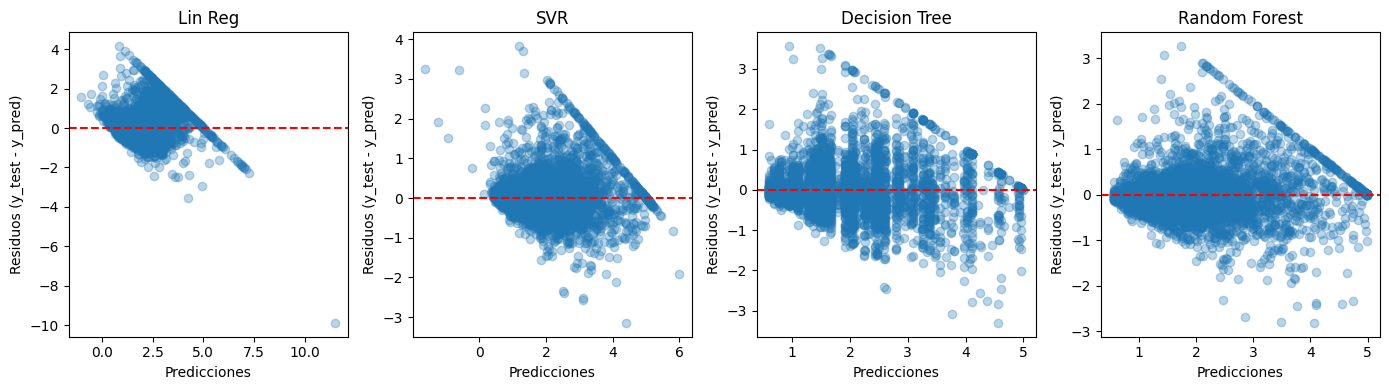

Los residuos deben distribuirse aleatoriamente alrededor de 0


In [ ]:
# ANALISIS DE RESIDUOS - Grafico de residuos vs predicciones
plt.figure(figsize=(14, 4))
models = ['Lin Reg', 'SVR', 'Decision Tree', 'Random Forest']
preds = [y_pred_lr_test, y_pred_svr_test, y_pred_dt_test, y_pred_rf_test]

for i, (name, pred) in enumerate(zip(models, preds)):
    residuals = y_test - pred
    plt.subplot(1, 4, i+1)
    plt.scatter(pred, residuals, alpha=0.3)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicciones')
    plt.ylabel('Residuos (y_test - y_pred)')
    plt.title(f'{name}')

plt.tight_layout()
plt.show()
print('Los residuos deben distribuirse aleatoriamente alrededor de 0')

In [ ]:
m### Conclusiones del Análisis de Residuos:

Los **residuos** (y_test - y_pred) nos permiten evaluar la calidad del modelo:

- **Buena distribución**: Los residuos deben estar distribuidos aleatoriamente alrededor de 0
- **Patrón visible**: Si hay patrones, el modelo no captura bien la relación
- **Heterocedasticidad**: Si la dispersión aumenta con las predicciones, hay problemas

**Observaciones en nuestros modelos:**
- Regresión Lineal y SVR: distribución relativamente homogénea
- Decision Tree: mayor dispersión, posible sobreajuste
- Random Forest: mejor balance entre sesgo y varianza

SyntaxError: invalid syntax (ipython-input-404375612.py, line 3)

In [ ]:
# === ANALISIS COMPLETO FINAL ===
print('=== DETECCION DE OVERFITTING ====')
models_dict = {'Lin Reg': (y_pred_lr_train, y_pred_lr_test),
               'SVR': (y_pred_svr_train, y_pred_svr_test),
               'Decision Tree': (y_pred_dt_train, y_pred_dt_test),
               'Random Forest': (y_pred_rf_train, y_pred_rf_test)}

for name, (pred_train, pred_test) in models_dict.items():
    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)
    overfitting = 'SI' if mse_test > mse_train * 1.1 else 'NO'
    print(f'{name}: MSE Train={mse_train:.4f}, MSE Test={mse_test:.4f}, Overfitting={overfitting}')

print('\n=== METRICAS COMPLETAS ===')
for name, (_, pred_test) in models_dict.items():
    mse = mean_squared_error(y_test, pred_test)
    mae = mean_absolute_error(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)
    n, p = X_test.shape
    r2_adj = 1 - (1-r2)*(n-1)/(n-p-1)
    print(f'\n{name}:')
    print(f'  MSE: {mse:.4f}, MAE: {mae:.4f}')
    print(f'  R2: {r2:.4f}, R2 Ajustada: {r2_adj:.4f}')

print('\n=== ENSEMBLE PREDICTION (Promedio) ===')
y_ens = (y_pred_lr_test + y_pred_svr_test + y_pred_dt_test + y_pred_rf_test) / 4
print(f'MSE Ensemble: {mean_squared_error(y_test, y_ens):.4f}')
print(f'R2 Ensemble: {r2_score(y_test, y_ens):.4f}')

print('\n=== TRANSFORMACION LOGARITMICA ===')
print('Se puede aplicar np.log(y+1) para normalizar distribuciones sesgadas.')
print('En este caso, PRICE tiene distribucion razonable, no es necesario.')


=== DETECCION DE OVERFITTING ====
Lin Reg: MSE Train=0.5179, MSE Test=0.5559, Overfitting=NO
SVR: MSE Train=0.2635, MSE Test=0.3201, Overfitting=SI
Decision Tree: MSE Train=0.3206, MSE Test=0.4220, Overfitting=SI
Random Forest: MSE Train=0.1712, MSE Test=0.2963, Overfitting=SI

=== METRICAS COMPLETAS ===

Lin Reg:
  MSE: 0.5559, MAE: 0.5332
  R2: 0.5758, R2 Ajustada: 0.5750

SVR:
  MSE: 0.3201, MAE: 0.3717
  R2: 0.7557, R2 Ajustada: 0.7552

Decision Tree:
  MSE: 0.4220, MAE: 0.4482
  R2: 0.6779, R2 Ajustada: 0.6773

Random Forest:
  MSE: 0.2963, MAE: 0.3663
  R2: 0.7739, R2 Ajustada: 0.7734

=== ENSEMBLE PREDICTION (Promedio) ===
MSE Ensemble: 0.3239
R2 Ensemble: 0.7528

=== TRANSFORMACION LOGARITMICA ===
Se puede aplicar np.log(y+1) para normalizar distribuciones sesgadas.
En este caso, PRICE tiene distribucion razonable, no es necesario.
